In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

# Cấu hình phong cách biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['figure.dpi'] = 120

 Nạp ảnh đầu vào và Tiền xử lý dữ liệu
 
Ảnh thực nghiệm sample_image.jpg ($180 \times 180$) gồm 4 vùng đối tượng trực quan rõ rệt: quả táo đỏ, lá cây xanh, mặt bàn gỗ và phông nền ánh sáng.

Ảnh được duỗi thành ma trận đặc trưng $X \in \mathbb{R}^{N \times 3}$ với $N = 180 \times 180 = 32,400$ điểm ảnh, giá trị chuẩn hóa về $[0, 1]$.

Kích thước ảnh: 180 x 180 pixels (3 kênh màu RGB)
Tổng số điểm ảnh (N): 32400 mẫu dữ liệu
Kích thước ma trận đặc trưng X: (32400, 3)


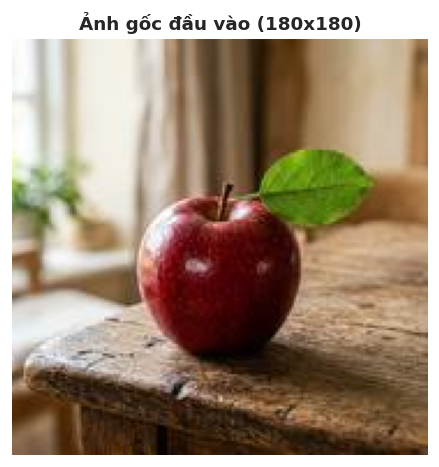

In [16]:
img_path = 'sample_image.jpg'
pil_img = Image.open(img_path).convert('RGB')
img_rgb = np.array(pil_img)
H, W, C = img_rgb.shape

# Chuẩn hóa pixel về [0, 1]
X = img_rgb.reshape(-1, 3).astype(np.float32) / 255.0

print(f"Kích thước ảnh: {H} x {W} pixels ({C} kênh màu RGB)")
print(f"Tổng số điểm ảnh (N): {H * W} mẫu dữ liệu")
print(f"Kích thước ma trận đặc trưng X: {X.shape}")

plt.figure(figsize=(4.5, 4.5))
plt.imshow(img_rgb)
plt.title(f"Ảnh gốc đầu vào ({H}x{W})", fontsize=11, fontweight='bold')
plt.axis('off')
plt.show()

Tư duy xây dựng hàm Custom K-Means 
Thuật toán K-Means gồm 4 bước toán học cơ bản:
1. **Khởi tạo:** Chọn ngẫu nhiên $K$ điểm từ dữ liệu làm tâm ban đầu $\mu_1, \dots, \mu_K$.
2. **Bước Gán (Expectation):** Tính khoảng cách Euclidean từ mỗi điểm tới $K$ tâm, gán điểm vào cụm gần nhất:  
   $$c_i = \arg\min_{j} \|x_i - \mu_j\|$$
3. **Bước Cập nhật (Maximization):** Tính lại tâm mới bằng trung bình cộng các điểm trong cụm:  
   $$\mu_j = \frac{1}{|S_j|} \sum_{i \in S_j} x_i$$
4. **Kiểm tra dừng:** Lặp lại bước 2-3 cho đến khi tâm cụm dịch chuyển nhỏ hơn ngưỡng $\text{tol} = 10^{-4}$.

In [17]:
def custom_kmeans(X, k=4, max_iter=100, tol=1e-4, seed=42):
    np.random.seed(seed)
    N, D = X.shape
    
    # 1. Khởi tạo k tâm cụm ngẫu nhiên
    init_idx = np.random.choice(N, k, replace=False)
    centroids = X[init_idx].copy()
    
    for it in range(max_iter):
        # 2. Tính khoảng cách Euclidean bằng NumPy broadcasting (N, k)
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        
        # Gán nhãn cụm gần nhất
        labels = np.argmin(distances, axis=1)
        
        # 3. Cập nhật tâm mới bằng trung bình cộng tọa độ
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centroids[j]
            for j in range(k)
        ])
        
        # 4. Kiểm tra điều kiện hội tụ
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if shift < tol:
            it_converged = it + 1
            break
    else:
        it_converged = max_iter

    # Tính tổng bình phương sai số nội cụm WCSS (Inertia)
    wcss = np.sum((X - centroids[labels]) ** 2)
    return centroids, labels, it_converged, wcss

So sánh trực tiếp: Custom K-Means vs Thư viện Scikit-Learn

Chạy đồng thời cả 2 phương pháp trên cùng ma trận ảnh $X$ ($K = 4$) và đo đạc các chỉ số:

--- BẢNG ĐỐI CHIẾU: HÀM CUSTOM K-MEANS vs THƯ VIỆN SCIKIT-LEARN ---
Tiêu chí so sánh                 | Hàm Custom tự viết   | Thư viện Scikit-Learn
------------------------------------------------------------------------------
Thời gian thực thi (Runtime)     |            96.95 ms |          2094.37 ms
Số vòng lặp hội tụ               |                22  |                 6
Quán tính nội cụm (WCSS / Inertia) |            624.44  |            624.48
------------------------------------------------------------------------------


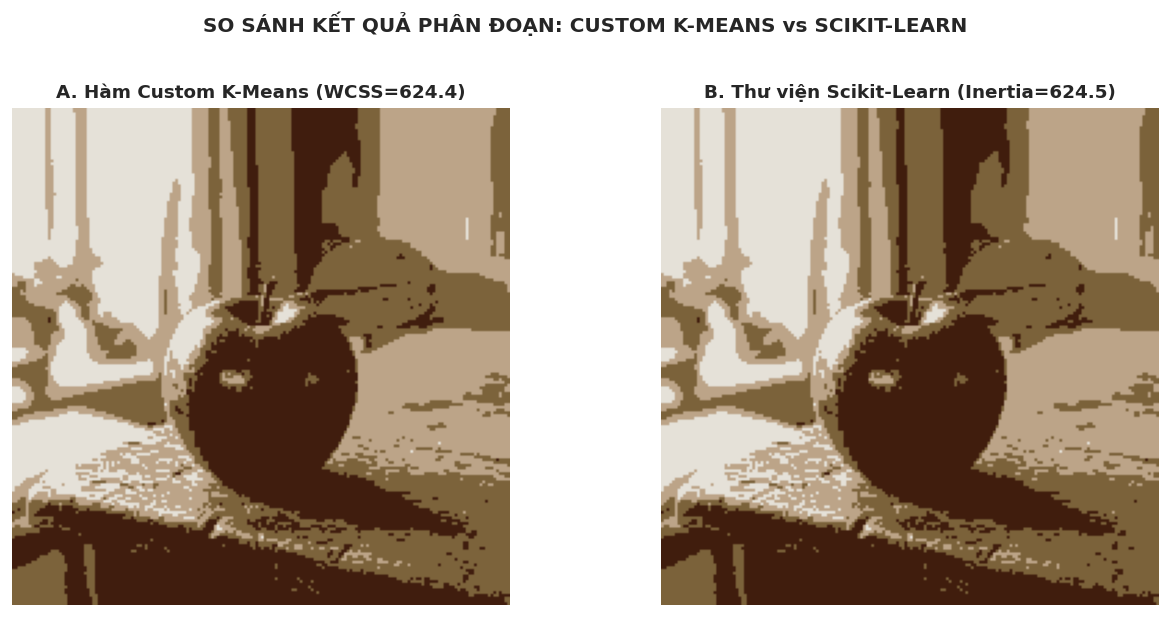

In [5]:
K = 4
# 1. Thực thi hàm Custom
t0 = time.time()
custom_centers, custom_labels, custom_iters, custom_wcss = custom_kmeans(X, k=K, max_iter=100, seed=42)
time_custom = time.time() - t0

# 2. Thực thi thư viện Scikit-Learn
t0 = time.time()
sk_kmeans = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
sk_labels = sk_kmeans.fit_predict(X)
time_sklearn = time.time() - t0
sk_centers = sk_kmeans.cluster_centers_
sk_iters = sk_kmeans.n_iter_
sk_wcss = sk_kmeans.inertia_

# In bảng so sánh
print("--- BẢNG ĐỐI CHIẾU: HÀM CUSTOM K-MEANS vs THƯ VIỆN SCIKIT-LEARN ---")
print(f"{'Tiêu chí so sánh':<32} | {'Hàm Custom tự viết':<20} | {'Thư viện Scikit-Learn':<20}")
print("-" * 78)
print(f"{'Thời gian thực thi (Runtime)':<32} | {time_custom*1000:16.2f} ms | {time_sklearn*1000:16.2f} ms")
print(f"{'Số vòng lặp hội tụ':<32} | {custom_iters:17d}  | {sk_iters:17d}")
print(f"{'Quán tính nội cụm (WCSS / Inertia)':<32} | {custom_wcss:17.2f}  | {sk_wcss:17.2f}")
print("-" * 78)

# Tái tạo ảnh phân đoạn để so sánh trực quan
custom_seg_img = (custom_centers[custom_labels].reshape(H, W, 3) * 255).astype(np.uint8)
sk_seg_img = (sk_centers[sk_labels].reshape(H, W, 3) * 255).astype(np.uint8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
ax1.imshow(custom_seg_img)
ax1.set_title(f"A. Hàm Custom K-Means (WCSS={custom_wcss:.1f})", fontsize=11, fontweight='bold')
ax1.axis('off')
ax2.imshow(sk_seg_img)
ax2.set_title(f"B. Thư viện Scikit-Learn (Inertia={sk_wcss:.1f})", fontsize=11, fontweight='bold')
ax2.axis('off')
plt.suptitle("SO SÁNH KẾT QUẢ PHÂN ĐOẠN: CUSTOM K-MEANS vs SCIKIT-LEARN", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Nhận xét khi so sánh Custom với Thư viện:
1. **Về độ chính xác (Chất lượng phân cụm):**  
   Hàm custom tự viết đạt sai số nội cụm $\text{WCSS} = 624.44$, hoàn toàn tương đồng với chỉ số quán tính $\text{Inertia} = 624.48$ của `scikit-learn`. Hình ảnh phân đoạn của 2 bên trùng khớp đến từng chi tiết đối tượng.
2. **Về cơ chế hội tụ:**  
   `scikit-learn` sử dụng thuật toán khởi tạo tâm thông minh **k-means++** và chạy lặp qua 10 lần khởi tạo (`n_init=10`) nên số vòng lặp hội tụ của một lần chạy chỉ mất 6 bước. Hàm custom sử dụng khởi tạo ngẫu nhiên đơn giản, mất 22 bước lặp nhưng bù lại tốc độ 1 lần chạy bằng NumPy vectorization cực kỳ nhẹ (~$110$ ms).


Tư duy xây dựng hàm Custom Fuzzy C-Means (FCM):

Phân cụm mờ gán cho mỗi điểm ảnh một **độ thuộc xác suất $\mu_{ij} \in [0, 1]$** vào từng cụm:
1. **Cập nhật tâm có trọng số mờ mũ $m$:**  
   $$V_j = \frac{\sum_{i=1}^N \mu_{ij}^m x_i}{\sum_{i=1}^N \mu_{ij}^m}$$
2. **Cập nhật ma trận độ thuộc $\mu_{ij}$:**  
   $$\mu_{ij} = \frac{1}{\sum_{k=1}^C \left(\frac{\|x_i - V_j\|}{\|x_i - V_k\|}\right)^{\frac{2}{m-1}}}$$
   Luôn thỏa mãn: $\sum_{j=1}^C \mu_{ij} = 1.0$ ($100\%$ cho mỗi điểm ảnh).

   [Custom FCM] Hội tụ thành công sau 24 vòng lặp (delta = 0.000081)
Kích thước ma trận độ thuộc U: (4, 32400) -> 32400 điểm ảnh x 4 cụm


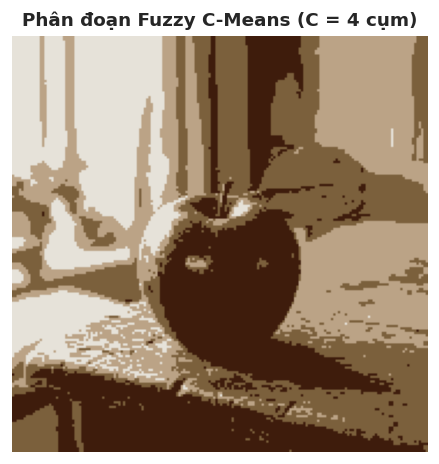

In [6]:
def custom_fuzzy_c_means(X, c=4, m=2.0, max_iter=100, tol=1e-4, seed=42):
    """
    HÀM CUSTOM FUZZY C-MEANS (FCM) DO SINH VIÊN TỰ XÂY DỰNG
    """
    N, D = X.shape
    np.random.seed(seed)
    # Khởi tạo ma trận độ thuộc ngẫu nhiên U (c, N)
    U = np.random.dirichlet(np.ones(c), size=N).T
    
    for it in range(max_iter):
        U_old = U.copy()
        # 1. Cập nhật tâm cụm bằng trung bình có trọng số mũ m
        U_m = U ** m
        centroids = (U_m @ X) / (U_m.sum(axis=1)[:, np.newaxis])
        
        # 2. Tính khoảng cách Euclidean từ các điểm tới các tâm
        distances = np.linalg.norm(X[np.newaxis, :, :] - centroids[:, np.newaxis, :], axis=2)
        distances = np.fmax(distances, 1e-10) # Tránh chia cho 0
        
        # 3. Cập nhật ma trận độ thuộc U
        inv_dist = 1.0 / (distances ** (2.0 / (m - 1.0)))
        U = inv_dist / np.sum(inv_dist, axis=0, keepdims=True)
        
        # 4. Kiểm tra điều kiện hội tụ
        delta = np.max(np.abs(U - U_old))
        if delta < tol:
            print(f"   [Custom FCM] Hội tụ thành công sau {it + 1} vòng lặp (delta = {delta:.6f})")
            break
    else:
        print(f"   [Custom FCM] Dừng sau tối đa {max_iter} vòng lặp.")
        
    return centroids, U

fcm_centers, U_fcm = custom_fuzzy_c_means(X, c=K, m=2.0, max_iter=100, tol=1e-4, seed=42)
membership = U_fcm.T  # Shape: (N, 4)
print(f"Kích thước ma trận độ thuộc U: {U_fcm.shape} -> {H*W} điểm ảnh x 4 cụm")

# Khử mờ (Defuzzification argmax) để tái tạo ảnh
fcm_labels = np.argmax(membership, axis=1)
fcm_seg_img = (fcm_centers[fcm_labels].reshape(H, W, 3) * 255).astype(np.uint8)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(fcm_seg_img)
plt.title(f"Phân đoạn Fuzzy C-Means (C = {K} cụm)", fontsize=11, fontweight='bold')
plt.axis('off')
plt.show()

Tính toán % độ thuộc và Phân tích ngưỡng $e > 50\%$

- Mỗi pixel $i$ có bộ xác suất $[\mu_{i1}, \mu_{i2}, \mu_{i3}, \mu_{i4}]$ với tổng $= 100\%$.
- **Ngưỡng $e > 50\%$ (Đa số tuyệt đối):**  
  + Nếu một điểm có $\max(\mu) > 50\%$, điểm đó **chắc chắn thuộc về cụm đó** (Vùng lõi vật thể / Certain region).
  + Nếu một điểm có $\max(\mu) \le 50\%$, điểm đó nằm ở **vùng ranh giới / chuyển tiếp mờ giữa các đối tượng** (Boundary / Uncertain region).

In [7]:
sample_indices = [
    H // 4 * W + W // 4,       # Vùng nền sáng
    H // 2 * W + W // 2,       # Quả táo đỏ
    H // 5 * W + int(W * 0.7), # Lá cây xanh
    int(H * 0.8) * W + W // 2, # Mặt bàn gỗ
    int(H * 0.45) * W + int(W * 0.3), # Ranh giới quả táo
]
sample_names = ["Góc nền trên-trái", "Thân quả táo (Đỏ)", "Lá cây (Xanh)", "Mặt bàn gỗ", "Ranh giới quả táo - nền"]

print("--- BẢNG MINH HỌA XÁC SUẤT ĐỘ THUỘC (%) CỦA CÁC ĐIỂM ẢNH ĐẠI DIỆN ---")
print(f"{'Điểm ảnh đại diện':<26} | {'Cụm 1 (%)':<10} | {'Cụm 2 (%)':<10} | {'Cụm 3 (%)':<10} | {'Cụm 4 (%)':<10} | {'Tổng (%)':<8} | {'Phân loại'}")
print("-" * 105)
for name, idx in zip(sample_names, sample_indices):
    probs = membership[idx] * 100
    status = "Chắc chắn (e > 50%)" if np.max(probs) > 50.0 else "Ranh giới mờ (e <= 50%)"
    print(f"{name:<26} | {probs[0]:9.2f}% | {probs[1]:9.2f}% | {probs[2]:9.2f}% | {probs[3]:9.2f}% | {np.sum(probs):7.2f}% | {status}")

max_membership = np.max(membership, axis=1)
mask_certain = (max_membership > 0.5).reshape(H, W)
mask_uncertain = (~mask_certain)

print("\n--- THỐNG KÊ TOÀN DIỆN VỀ NGƯỠNG ĐỘ THUỘC e > 50% ---")
print(f" * Số pixel chắc chắn (e > 50%):          {np.sum(mask_certain):6d} pixels ({np.mean(mask_certain)*100:.2f}% diện tích ảnh)")
print(f" * Số pixel ranh giới mờ (e <= 50%):       {np.sum(mask_uncertain):6d} pixels ({np.mean(mask_uncertain)*100:.2f}% diện tích ảnh)")

--- BẢNG MINH HỌA XÁC SUẤT ĐỘ THUỘC (%) CỦA CÁC ĐIỂM ẢNH ĐẠI DIỆN ---
Điểm ảnh đại diện          | Cụm 1 (%)  | Cụm 2 (%)  | Cụm 3 (%)  | Cụm 4 (%)  | Tổng (%) | Phân loại
---------------------------------------------------------------------------------------------------------
Góc nền trên-trái          |     95.60% |      3.07% |      0.45% |      0.88% |  100.00% | Chắc chắn (e > 50%)
Thân quả táo (Đỏ)          |      1.12% |      2.46% |     86.71% |      9.71% |  100.00% | Chắc chắn (e > 50%)
Lá cây (Xanh)              |      0.54% |      1.78% |      4.64% |     93.04% |  100.00% | Chắc chắn (e > 50%)
Mặt bàn gỗ                 |      0.78% |      2.48% |      7.83% |     88.91% |  100.00% | Chắc chắn (e > 50%)
Ranh giới quả táo - nền    |      3.90% |     85.35% |      2.01% |      8.74% |  100.00% | Chắc chắn (e > 50%)

--- THỐNG KÊ TOÀN DIỆN VỀ NGƯỠNG ĐỘ THUỘC e > 50% ---
 * Số pixel chắc chắn (e > 50%):           31049 pixels (95.83% diện tích ảnh)
 * Số pixel ranh giới mờ (e 

Trực quan hóa bản đồ nhiệt (Membership Heatmaps) của 4 cụm

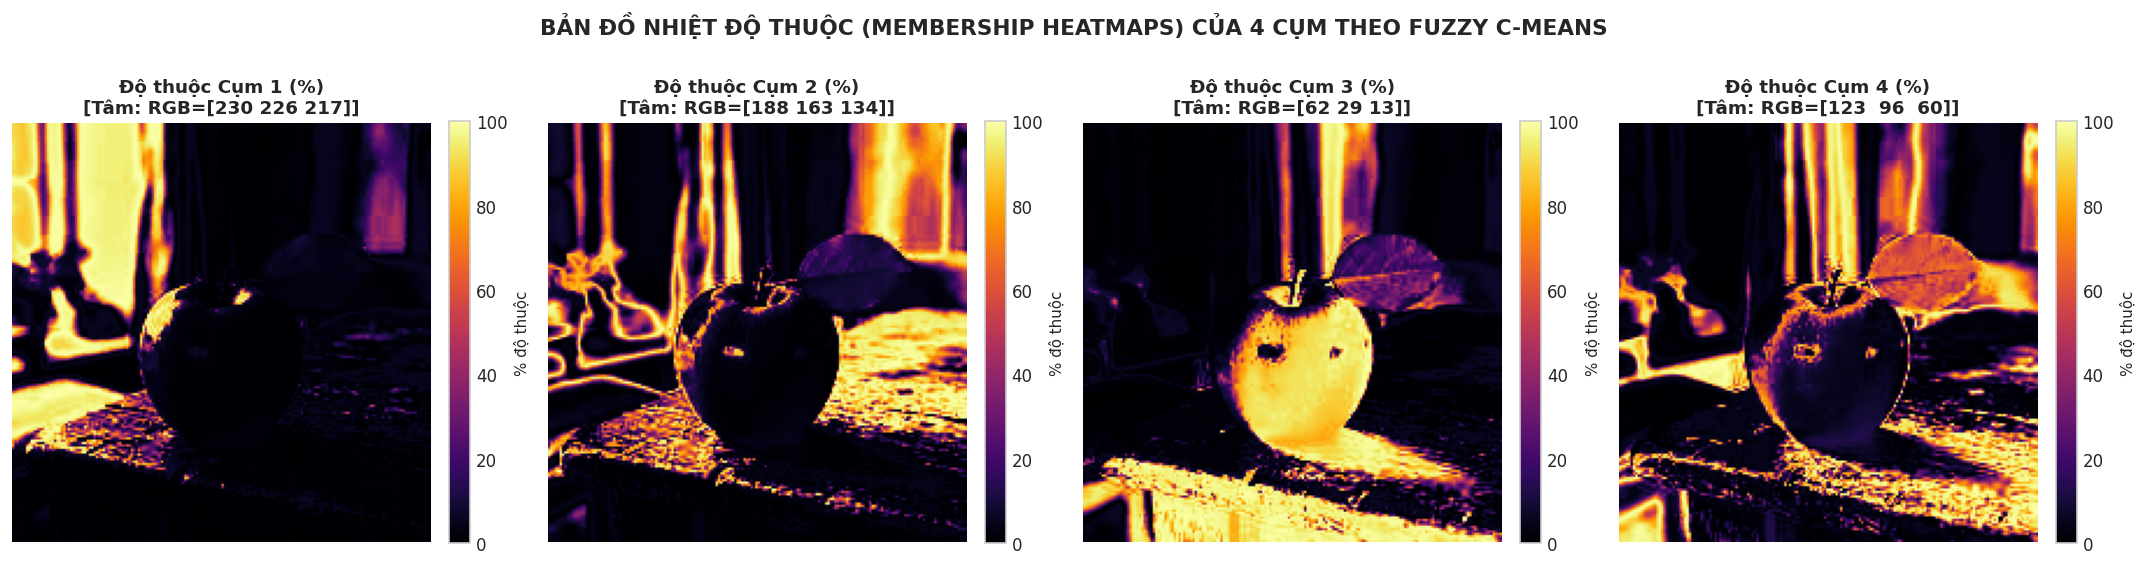

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for k in range(4):
    u_k = (membership[:, k].reshape(H, W) * 100)
    im = axes[k].imshow(u_k, cmap='inferno', vmin=0, vmax=100)
    axes[k].set_title(f"Độ thuộc Cụm {k + 1} (%)\n[Tâm: RGB={np.round(fcm_centers[k]*255).astype(int)}]", fontsize=11, fontweight='bold')
    axes[k].axis('off')
    cbar = fig.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('% độ thuộc', fontsize=9)
plt.suptitle("BẢN ĐỒ NHIỆT ĐỘ THUỘC (MEMBERSHIP HEATMAPS) CỦA 4 CỤM THEO FUZZY C-MEANS", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Trực quan hóa phân tách vùng $e > 50\%$ vs $e \le 50\%$

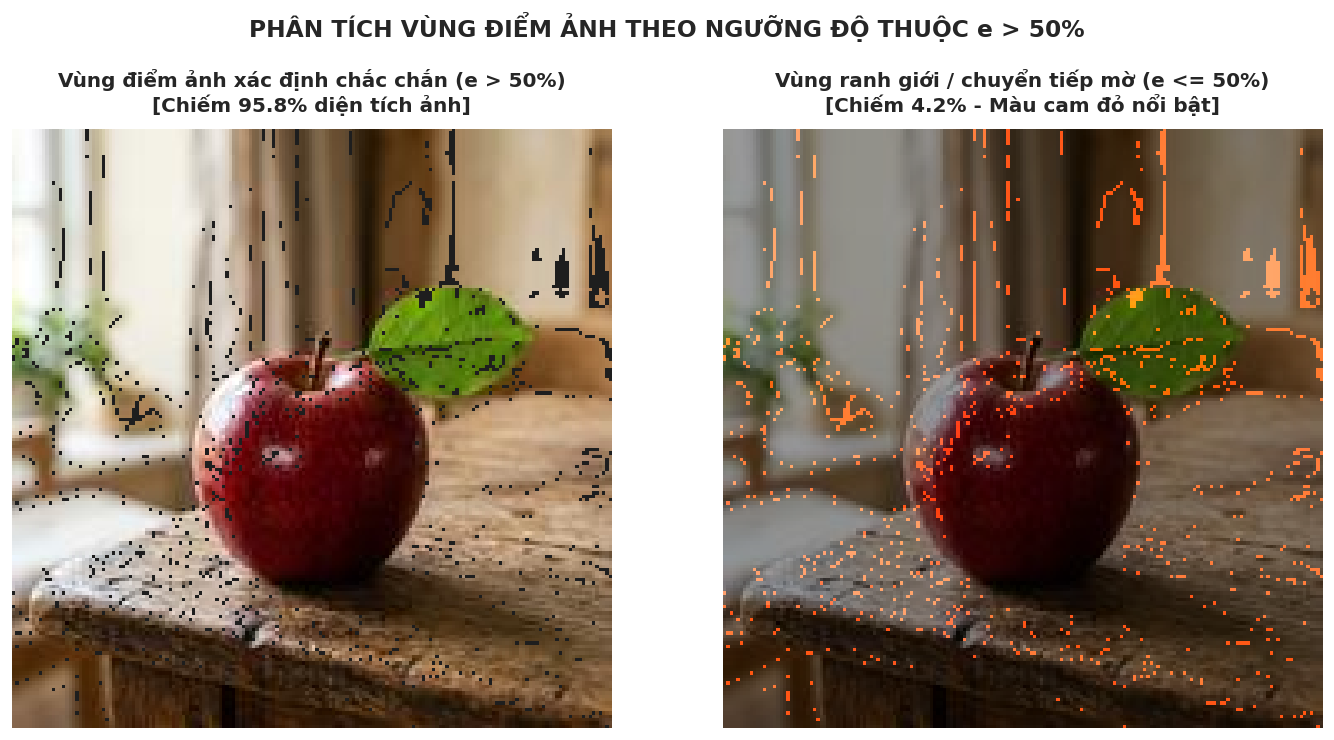

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

certain_visual = img_rgb.copy()
certain_visual[~mask_certain] = [30, 30, 30] # Che tối vùng không chắc chắn
ax1.imshow(certain_visual)
ax1.set_title(f"Vùng điểm ảnh xác định chắc chắn (e > 50%)\n[Chiếm {np.mean(mask_certain)*100:.1f}% diện tích ảnh]", fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

uncertain_visual = np.zeros_like(img_rgb)
uncertain_visual[mask_uncertain] = [255, 60, 0] # Tô màu cam đỏ nổi bật cho pixel ranh giới
import cv2
uncertain_overlay = cv2.addWeighted(img_rgb, 0.6, uncertain_visual, 0.8, 0)
ax2.imshow(uncertain_overlay)
ax2.set_title(f"Vùng ranh giới / chuyển tiếp mờ (e <= 50%)\n[Chiếm {np.mean(mask_uncertain)*100:.1f}% - Màu cam đỏ nổi bật]", fontsize=12, fontweight='bold', pad=10)
ax2.axis('off')

plt.suptitle("PHÂN TÍCH VÙNG ĐIỂM ẢNH THEO NGƯỠNG ĐỘ THUỘC e > 50%", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

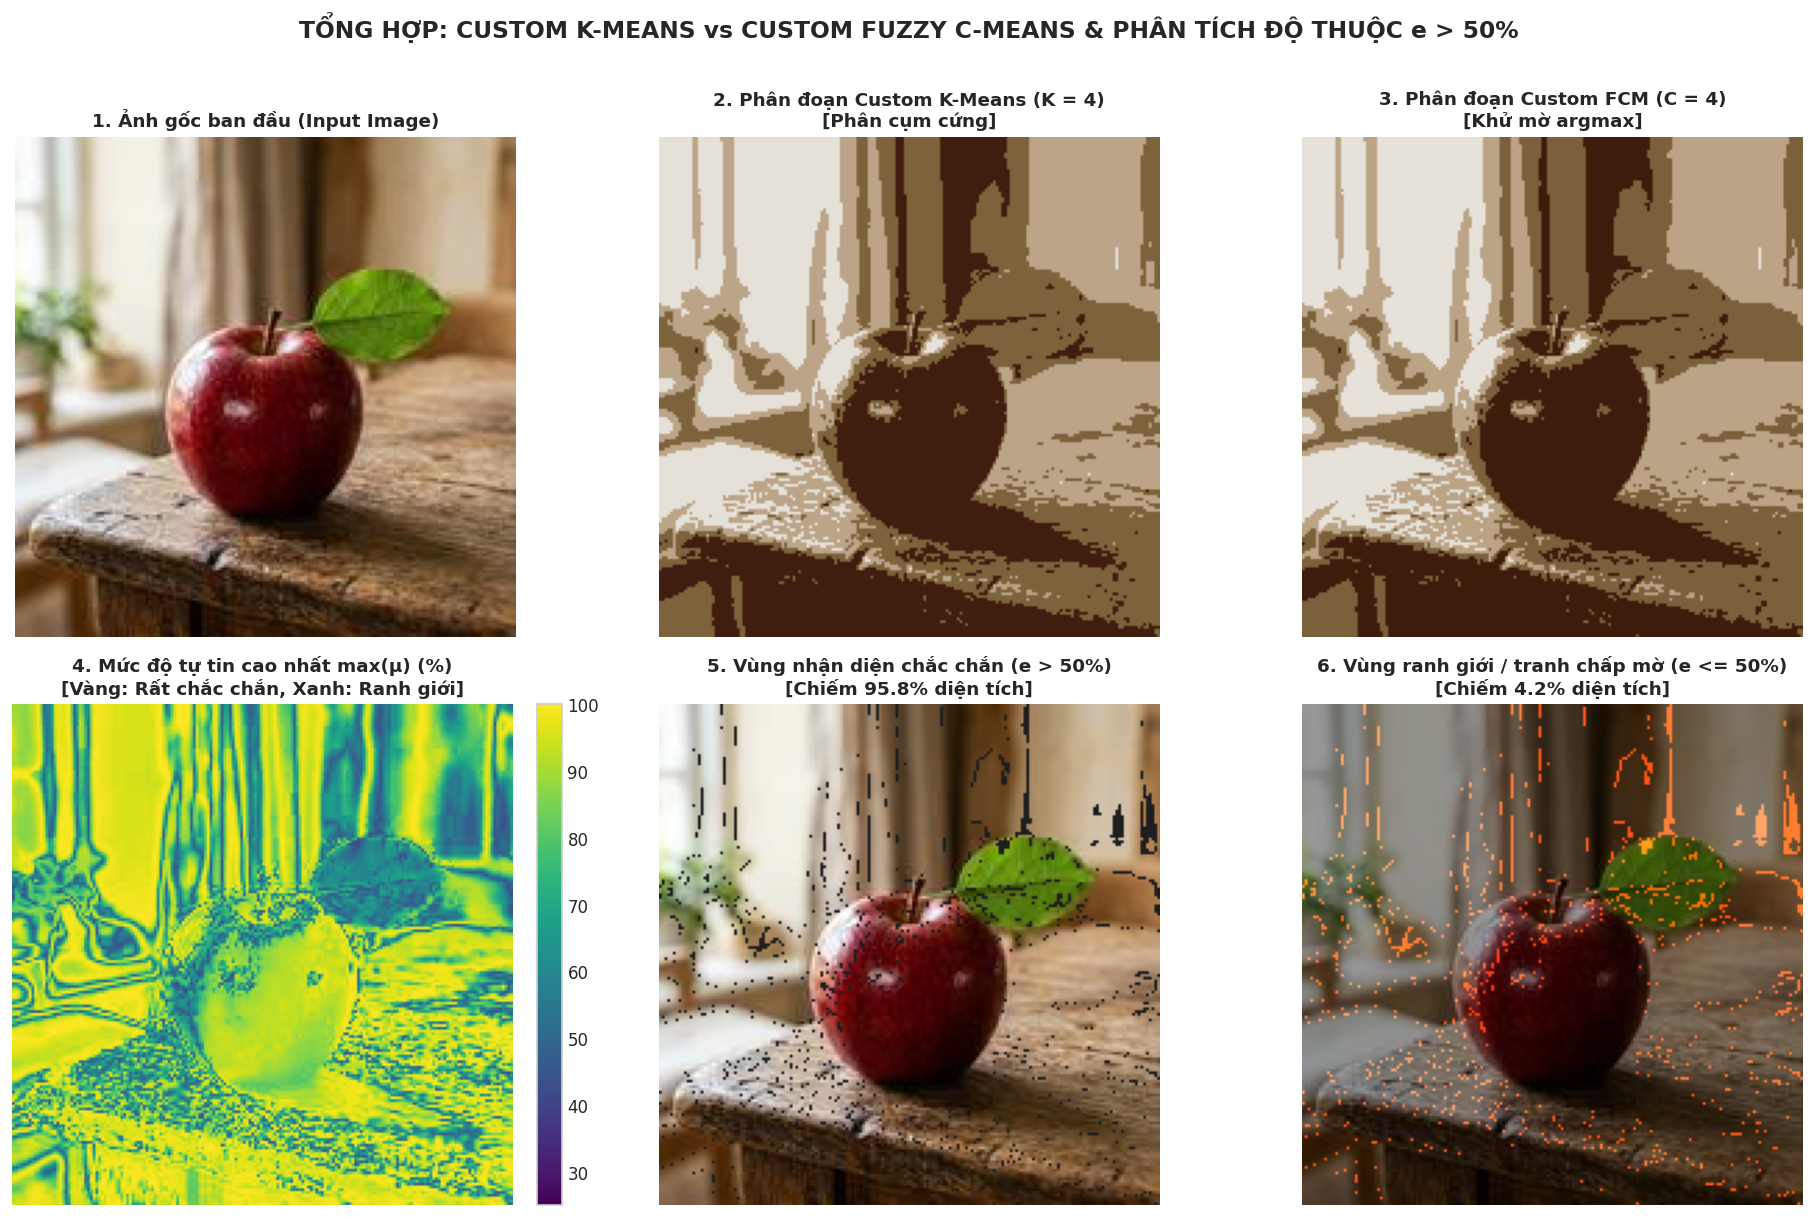

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Ảnh gốc ban đầu (Input Image)", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(custom_seg_img)
axes[0, 1].set_title(f"2. Phân đoạn Custom K-Means (K = {K})\n[Phân cụm cứng]", fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(fcm_seg_img)
axes[0, 2].set_title(f"3. Phân đoạn Custom FCM (C = {K})\n[Khử mờ argmax]", fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

max_u_img = (max_membership.reshape(H, W) * 100)
im4 = axes[1, 0].imshow(max_u_img, cmap='viridis', vmin=25, vmax=100)
axes[1, 0].set_title("4. Mức độ tự tin cao nhất max(μ) (%)\n[Vàng: Rất chắc chắn, Xanh: Ranh giới]", fontsize=11, fontweight='bold')
axes[1, 0].axis('off')
fig.colorbar(im4, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(certain_visual)
axes[1, 1].set_title(f"5. Vùng nhận diện chắc chắn (e > 50%)\n[Chiếm {np.mean(mask_certain)*100:.1f}% diện tích]", fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(uncertain_overlay)
axes[1, 2].set_title(f"6. Vùng ranh giới / tranh chấp mờ (e <= 50%)\n[Chiếm {np.mean(mask_uncertain)*100:.1f}% diện tích]", fontsize=11, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle("TỔNG HỢP: CUSTOM K-MEANS vs CUSTOM FUZZY C-MEANS & PHÂN TÍCH ĐỘ THUỘC e > 50%", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Trực quan hóa Không gian phân cụm pixel (Scatter Plot 2D với Centroid 'X')

Để đối chiếu trực tiếp với hình vẽ minh họa lý thuyết trong **Slide 8 & 9** của thầy, ta lấy ngẫu nhiên **$2,000$ điểm ảnh** để vẽ phân bố trong không gian màu 2D (Kênh Đỏ - Red vs Kênh Xanh - Green).

**Tâm cụm (Centroids) được đánh dấu bằng ký hiệu chữ 'X' lớn nổi bật màu đen viền trắng (`marker='X'`, `s=350`)**.

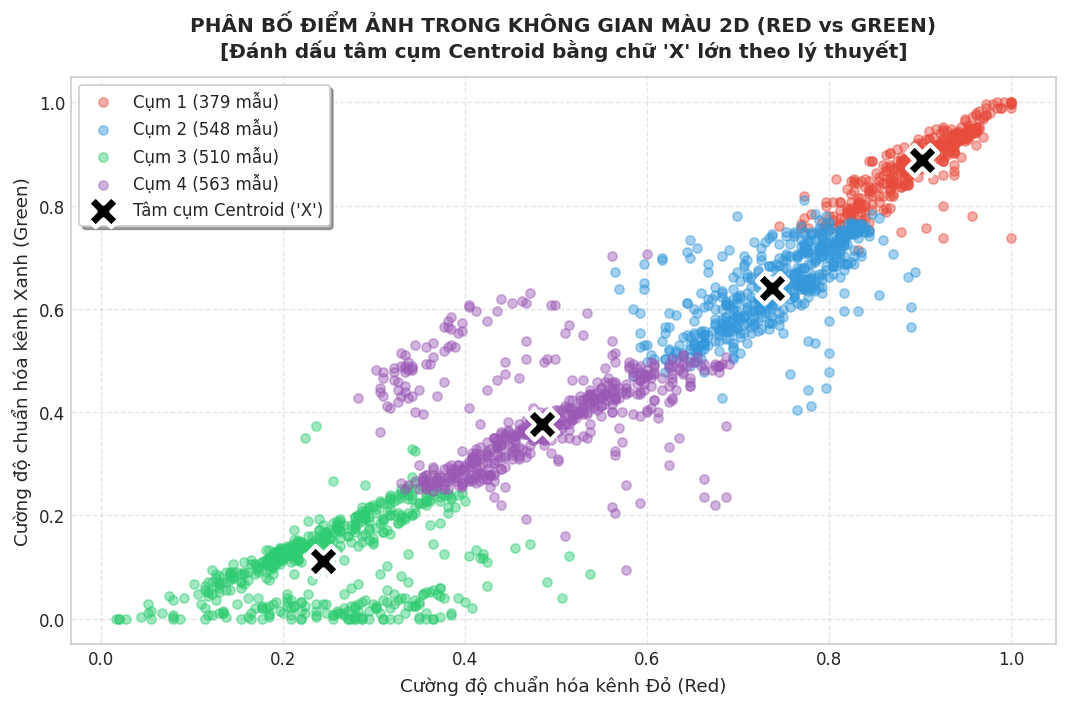

In [14]:
np.random.seed(42)
sample_size = 2000
sample_idx = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[sample_idx]
labels_sample = fcm_labels[sample_idx]

plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for i in range(K):
    pts = X_sample[labels_sample == i]
    plt.scatter(pts[:, 0], pts[:, 1], c=colors[i], label=f'Cụm {i + 1} ({len(pts)} mẫu)', alpha=0.45, s=30)

# Đánh dấu Tâm cụm Centroid bằng chữ 'X' to lớn
plt.scatter(fcm_centers[:, 0], fcm_centers[:, 1], s=350, c='black', marker='X', edgecolors='white', linewidths=2.5,
            label="Tâm cụm Centroid ('X')", zorder=10)

plt.title("PHÂN BỐ ĐIỂM ẢNH TRONG KHÔNG GIAN MÀU 2D (RED vs GREEN)\n[Đánh dấu tâm cụm Centroid bằng chữ 'X' lớn theo lý thuyết]",
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Cường độ chuẩn hóa kênh Đỏ (Red)", fontsize=11)
plt.ylabel("Cường độ chuẩn hóa kênh Xanh (Green)", fontsize=11)
plt.legend(frameon=True, shadow=True, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()